Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries loaded
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB
✅ Configuration loaded
   FASTA       : /content/drive/MyDrive/Colab Notebooks/AIP_V2/data/AIP.fasta
   Output dir  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features
   Figures dir : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
   Model       : Rostlab/prot_bert_bfd
   Batch size  : 16
   Pooling     : mean
✅ Parsed 2435 sequences
   Positive (AIP)    : 974
   Negative (non-AIP): 1461
   Length range      : 11 – 46 aa

Loading ProtBERT model: Rostlab/prot_bert_bfd
(Loading model.safetensors from HuggingFace cache)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Rostlab/prot_bert_bfd
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully
   Hidden size     : 1024
   Num layers      : 30
   Attention heads : 16
Original  : PRIVLDVASSVF
Processed : P R I V L D V A S S V F

Extracting embeddings...
  Sequences  : 2435
  Batches    : 153
  Pooling    : mean
  Device     : cuda
  [5/153] 80/2435 done
  [10/153] 160/2435 done
  [15/153] 240/2435 done
  [20/153] 320/2435 done
  [25/153] 400/2435 done
  [30/153] 480/2435 done
  [35/153] 560/2435 done
  [40/153] 640/2435 done
  [45/153] 720/2435 done
  [50/153] 800/2435 done
  [55/153] 880/2435 done
  [60/153] 960/2435 done
  [65/153] 1040/2435 done
  [70/153] 1120/2435 done
  [75/153] 1200/2435 done
  [80/153] 1280/2435 done
  [85/153] 1360/2435 done
  [90/153] 1440/2435 done
  [95/153] 1520/2435 done
  [100/153] 1600/2435 done
  [105/153] 1680/2435 done
  [110/153] 1760/2435 done
  [115/153] 1840/2435 done
  [120/153] 1920/2435 done
  [125/153] 2000/2435 done
  [130/153] 2080/2435 done
  [135/153] 2160/2435 done
  [140/153] 2240/2435 done
  [145/15

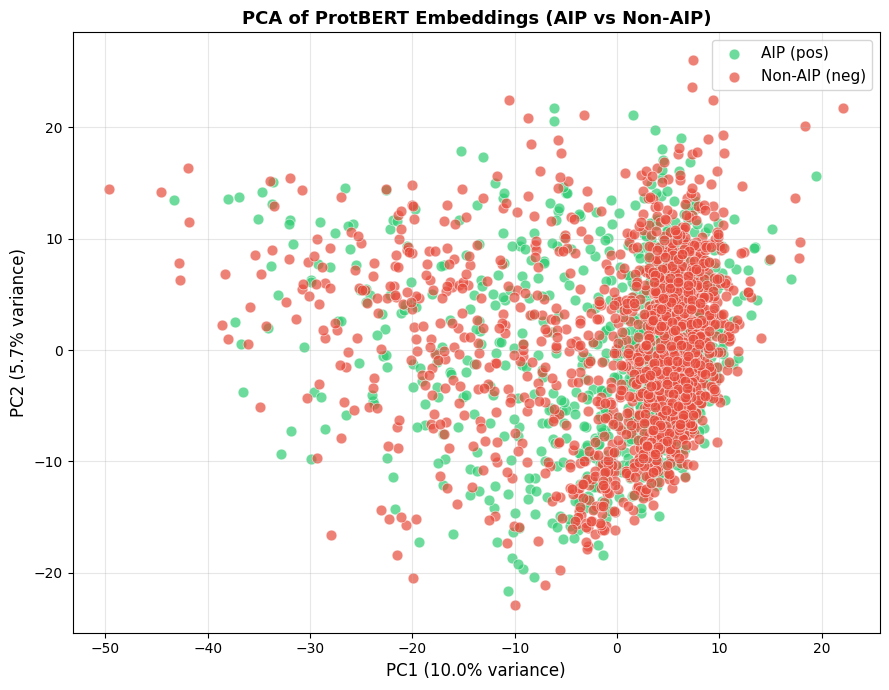

✅ PCA plot saved

Running t-SNE (~30 seconds)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


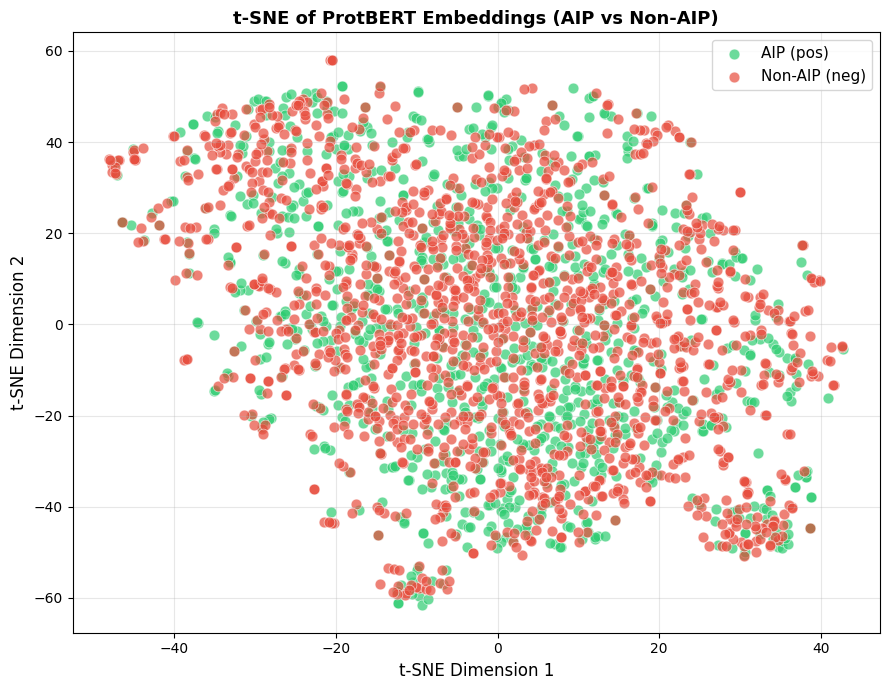

✅ t-SNE plot saved

Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


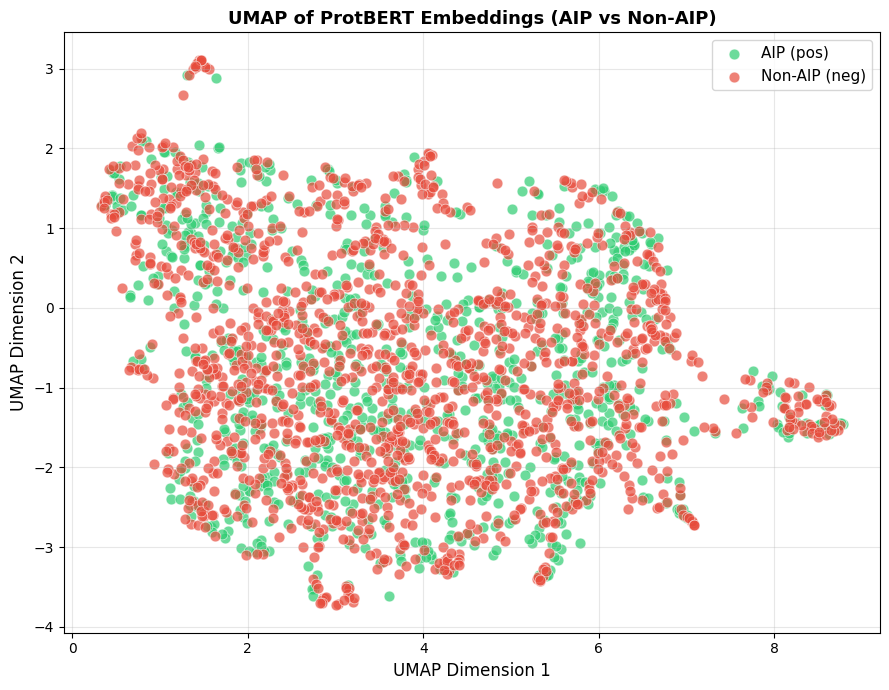

✅ UMAP plot saved


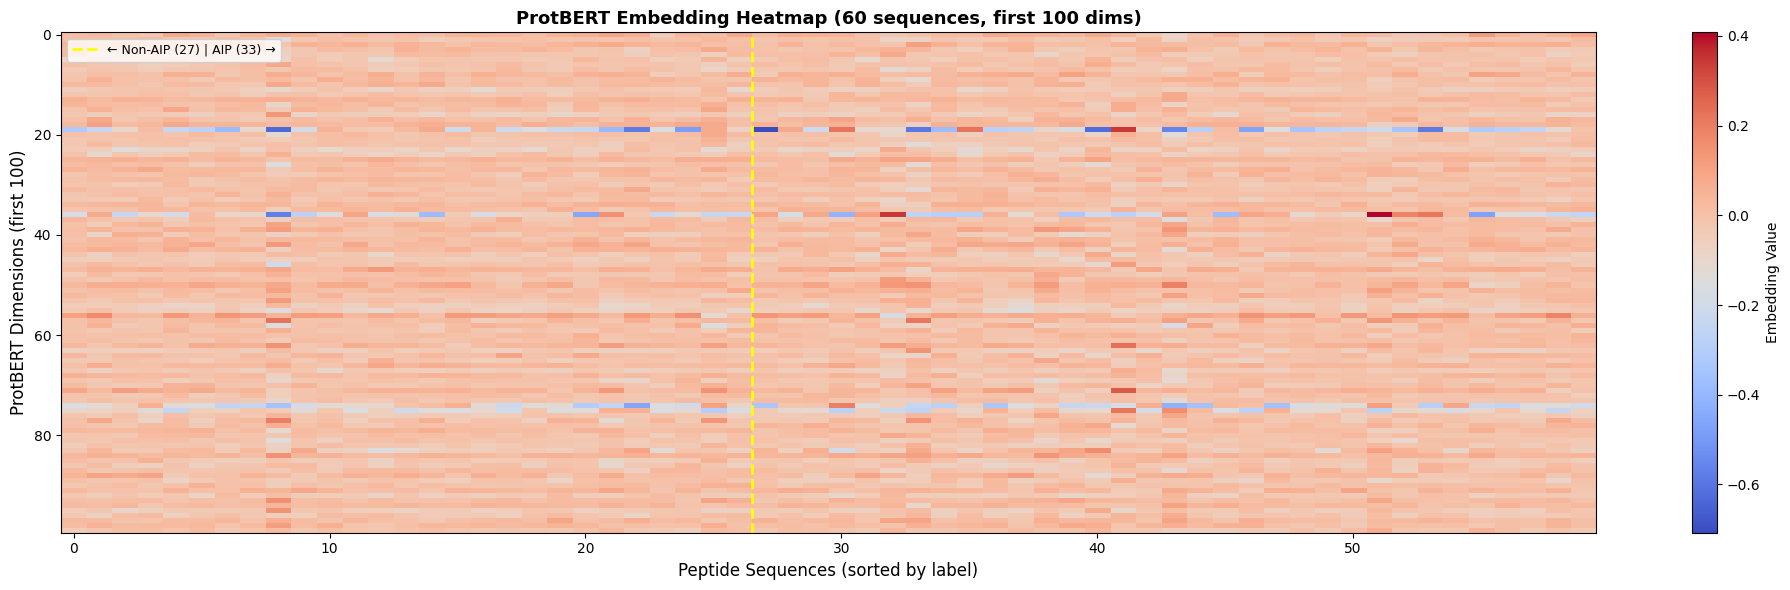

✅ Embedding heatmap saved


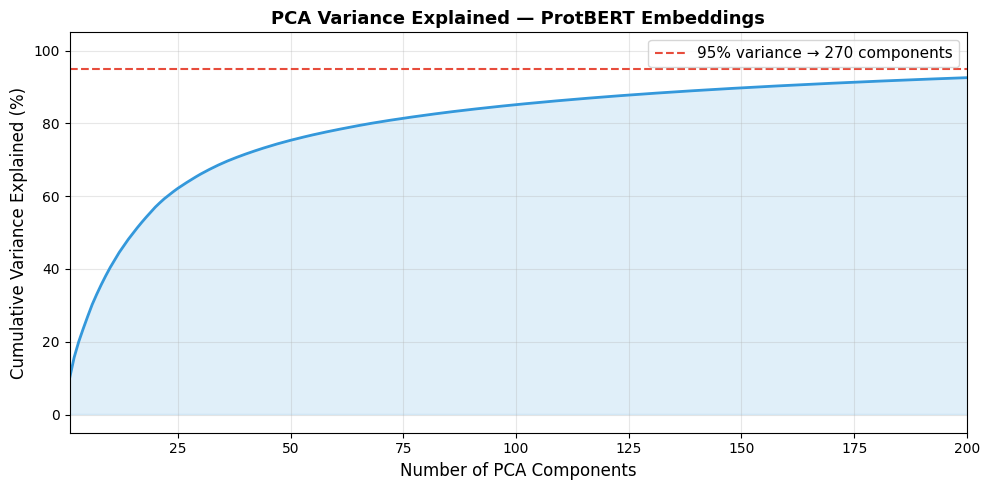

✅ PCA variance plot saved
   270 components explain 95% variance (vs full 1024 dims)
✅ PCA-reduced features saved
   File  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtBERT_PCA_features.csv
   Shape : (2435, 272)  (270 dims vs original 1024)

✅ ProtBERT Feature Extraction COMPLETE
   Full CSV     : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtBERT_features.csv
   Shape        : (2435, 1026)
   Raw .npy     : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtBERT_embeddings.npy
   PCA CSV      : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ProtBERT_PCA_features.csv
   PCA shape    : (2435, 272)
   Figures      : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
   Model        : Rostlab/prot_bert_bfd
   Pooling      : mean
   Fix applied  : use_safetensors=True (CVE-2025-32434)


In [3]:
# ============================================================
#   protBERT.py
#   ProtBERT feature extraction for AIP prediction
#
#   ✅ FIX APPLIED: use_safetensors=True in from_pretrained()
#      Root cause: CVE-2025-32434 — torch.load is blocked in
#      transformers when torch < 2.6. Passing use_safetensors=True
#      loads model.safetensors instead, which does not use
#      torch.load at all. The safetensors file was already
#      downloaded to your HuggingFace cache during the failed
#      run, so this loads instantly from cache.
# ============================================================


# ============================================================
#   CELL 1 — Mount Google Drive (Colab only)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Import Libraries
# ============================================================

import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import BertModel, BertTokenizer
from torch.utils.data import DataLoader, Dataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries loaded")
print(f"   Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("   ⚠️  No GPU — running on CPU (will be slower)")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

# ── Google Colab paths ────────────────────────────────────────
FASTA_PATH  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/data/AIP.fasta"
OUTPUT_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/features"
FIGURES_DIR = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/figures"

# ── Local paths ───────────────────────────────────────────────
# FASTA_PATH  = "../../../data/raw/AIP_v2.fasta"
# OUTPUT_DIR  = "../../../data/features/v2"
# FIGURES_DIR = "../../../results/figures/features/v2"

OUTPUT_CSV  = os.path.join(OUTPUT_DIR, "ProtBERT_features.csv")
OUTPUT_NPY  = os.path.join(OUTPUT_DIR, "ProtBERT_embeddings.npy")

# ── Model settings ────────────────────────────────────────────
# "Rostlab/prot_bert"     → base model (768-dim)
# "Rostlab/prot_bert_bfd" → trained on BFD database (recommended)
MODEL_NAME  = "Rostlab/prot_bert_bfd"
BATCH_SIZE  = 16      # reduce to 8 if memory errors occur
POOLING     = "mean"  # "mean" | "cls" | "max"

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"✅ Configuration loaded")
print(f"   FASTA       : {FASTA_PATH}")
print(f"   Output dir  : {OUTPUT_DIR}")
print(f"   Figures dir : {FIGURES_DIR}")
print(f"   Model       : {MODEL_NAME}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Pooling     : {POOLING}")


# ============================================================
#   CELL 4 — FASTA Parser
# ============================================================

def parse_fasta(filepath):
    """Parse FASTA file → DataFrame with seq_id, sequence, label."""
    entries    = []
    current_id = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                current_id = line[1:]
            elif line and current_id:
                label = 1 if current_id.startswith("pos") else 0
                entries.append({
                    "seq_id"  : current_id,
                    "sequence": line.upper(),
                    "label"   : label
                })

    df = pd.DataFrame(entries)
    print(f"✅ Parsed {len(df)} sequences")
    print(f"   Positive (AIP)    : {df['label'].sum()}")
    print(f"   Negative (non-AIP): {(df['label']==0).sum()}")
    print(f"   Length range      : "
          f"{df['sequence'].apply(len).min()} – "
          f"{df['sequence'].apply(len).max()} aa")
    return df

df_seq = parse_fasta(FASTA_PATH)


# ============================================================
#   CELL 5 — Load ProtBERT Model & Tokenizer
#
#   ✅ FIX: use_safetensors=True
#
#   Without this flag, transformers loads pytorch_model.bin
#   via torch.load() which raises:
#     ValueError: Due to a serious vulnerability issue in
#     torch.load, we now require torch >= v2.6
#     (CVE-2025-32434)
#
#   use_safetensors=True loads model.safetensors instead,
#   which uses a completely different, safe loading mechanism
#   that does not call torch.load() at all.
# ============================================================

print(f"\nLoading ProtBERT model: {MODEL_NAME}")
print("(Loading model.safetensors from HuggingFace cache)")

tokenizer = BertTokenizer.from_pretrained(
    MODEL_NAME,
    do_lower_case=False
)

# ✅ THE FIX — one parameter added
model = BertModel.from_pretrained(
    MODEL_NAME,
    use_safetensors=True    # ← bypasses torch.load vulnerability
)
model = model.to(DEVICE)
model.eval()

print(f"✅ Model loaded successfully")
print(f"   Hidden size     : {model.config.hidden_size}")
print(f"   Num layers      : {model.config.num_hidden_layers}")
print(f"   Attention heads : {model.config.num_attention_heads}")


# ============================================================
#   CELL 6 — Sequence Preprocessing
# ============================================================

def preprocess_sequence(sequence):
    """
    Format a protein sequence for ProtBERT.
    - Replace non-standard amino acids (B, Z, U, O, J) with X
    - Insert spaces between every amino acid
      "ACDE" → "A C D E"
    This format is required by the ProtBERT tokenizer.
    """
    sequence = re.sub(r"[BUZOJ]", "X", sequence.upper())
    return " ".join(list(sequence))

sample_seq = df_seq["sequence"].iloc[0]
print(f"Original  : {sample_seq}")
print(f"Processed : {preprocess_sequence(sample_seq)}")


# ============================================================
#   CELL 7 — PyTorch Dataset
# ============================================================

class PeptideDataset(Dataset):
    """Dataset wrapper for batched ProtBERT inference."""

    def __init__(self, sequences, tokenizer, max_length=512):
        self.sequences  = [preprocess_sequence(s) for s in sequences]
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.sequences[idx],
            return_tensors     = "pt",
            padding            = "max_length",
            truncation         = True,
            max_length         = self.max_length,
            add_special_tokens = True
        )
        return {
            "input_ids"     : encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }


# ============================================================
#   CELL 8 — Pooling Helper
# ============================================================

def pool_embeddings(hidden_states, attention_mask, strategy="mean"):
    """
    Aggregate token-level embeddings → one vector per sequence.

    mean — average over non-padding tokens (recommended)
    cls  — [CLS] token at position 0
    max  — element-wise max over non-padding tokens
    """
    if strategy == "cls":
        return hidden_states[:, 0, :]

    mask = attention_mask.unsqueeze(-1).float()

    if strategy == "mean":
        sum_emb = (hidden_states * mask).sum(dim=1)
        count   = mask.sum(dim=1).clamp(min=1e-9)
        return sum_emb / count

    elif strategy == "max":
        hidden_states[mask == 0] = -1e9
        return hidden_states.max(dim=1).values

    raise ValueError(f"Unknown pooling strategy: {strategy}")


# ============================================================
#   CELL 9 — Embedding Extraction
# ============================================================

def extract_protbert_embeddings(df, tokenizer, model, device,
                                 batch_size=BATCH_SIZE,
                                 pooling=POOLING):
    """Extract ProtBERT embeddings for all sequences."""

    sequences = df["sequence"].tolist()
    dataset   = PeptideDataset(sequences, tokenizer)
    loader    = DataLoader(dataset, batch_size=batch_size,
                           shuffle=False, num_workers=0)

    all_embeddings = []
    total_batches  = len(loader)

    print(f"\nExtracting embeddings...")
    print(f"  Sequences  : {len(sequences)}")
    print(f"  Batches    : {total_batches}")
    print(f"  Pooling    : {pooling}")
    print(f"  Device     : {device}")

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):

            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

            hidden_states = outputs.last_hidden_state

            pooled = pool_embeddings(
                hidden_states, attention_mask, strategy=pooling
            )

            all_embeddings.append(pooled.cpu().numpy())

            if (batch_idx + 1) % 5 == 0 or \
               (batch_idx + 1) == total_batches:
                done = min((batch_idx + 1) * batch_size,
                           len(sequences))
                print(f"  [{batch_idx+1}/{total_batches}] "
                      f"{done}/{len(sequences)} done")

    embeddings = np.vstack(all_embeddings)
    print(f"\n✅ Extraction complete — shape: {embeddings.shape}")
    return embeddings

embeddings = extract_protbert_embeddings(
    df_seq, tokenizer, model, DEVICE
)


# ============================================================
#   CELL 10 — Build Feature DataFrame
# ============================================================

embedding_dim = embeddings.shape[1]
col_names     = [f"ProtBERT_{i}" for i in range(embedding_dim)]

df_emb      = pd.DataFrame(embeddings, columns=col_names)
df_protbert = pd.concat([
    df_seq[["seq_id", "sequence", "label"]].reset_index(drop=True),
    df_emb
], axis=1)

# Drop sequence column, move label to last position
df_protbert = df_protbert.drop(columns=["sequence"])
cols        = [c for c in df_protbert.columns
               if c != "label"] + ["label"]
df_protbert = df_protbert[cols]

print(f"✅ Feature DataFrame built")
print(f"   Shape   : {df_protbert.shape}")
print(f"   Columns : seq_id | ProtBERT_0..{embedding_dim-1} | label")
print(df_protbert.iloc[:3, :6])


# ============================================================
#   CELL 11 — Validation
# ============================================================

emb_cols = [c for c in df_protbert.columns
            if c.startswith("ProtBERT_")]

print("\n── Validation ──────────────────────────────────")
print(f"Embedding dim  : {len(emb_cols)}")
print(f"Missing values : {df_protbert[emb_cols].isnull().sum().sum()}")
print(f"Value range    : {df_protbert[emb_cols].values.min():.4f}"
      f" – {df_protbert[emb_cols].values.max():.4f}")
print(f"Mean (pos)     : "
      f"{df_protbert[df_protbert['label']==1][emb_cols].values.mean():.4f}")
print(f"Mean (neg)     : "
      f"{df_protbert[df_protbert['label']==0][emb_cols].values.mean():.4f}")
print("✅ Validation passed")


# ============================================================
#   CELL 12 — Visualization 1: PCA
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("\nRunning PCA...")
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_protbert[emb_cols].values)

pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_protbert["label"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, alpha=0.7,
               s=60, edgecolors="white", linewidths=0.5)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("PCA of ProtBERT Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtBERT_PCA.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ PCA plot saved")


# ============================================================
#   CELL 13 — Visualization 2: t-SNE
# ============================================================

from sklearn.manifold import TSNE

print("\nRunning t-SNE (~30 seconds)...")
tsne   = TSNE(n_components=2, random_state=42,
              perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_protbert["label"] == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=name, alpha=0.7,
               s=60, edgecolors="white", linewidths=0.5)

ax.set_xlabel("t-SNE Dimension 1", fontsize=12)
ax.set_ylabel("t-SNE Dimension 2", fontsize=12)
ax.set_title("t-SNE of ProtBERT Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtBERT_tSNE.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ t-SNE plot saved")


# ============================================================
#   CELL 14 — Visualization 3: UMAP
# ============================================================

try:
    import umap
except ImportError:
    print("Installing umap-learn...")
    import subprocess
    subprocess.run(["pip", "install", "umap-learn", "-q"])
    import umap

print("\nRunning UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=15, min_dist=0.1)
X_umap  = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_protbert["label"] == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=color, label=name, alpha=0.7,
               s=60, edgecolors="white", linewidths=0.5)

ax.set_xlabel("UMAP Dimension 1", fontsize=12)
ax.set_ylabel("UMAP Dimension 2", fontsize=12)
ax.set_title("UMAP of ProtBERT Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtBERT_UMAP.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ UMAP plot saved")


# ============================================================
#   CELL 15 — Visualization 4: Embedding Heatmap
# ============================================================

sample     = df_protbert.sample(
    min(60, len(df_protbert)), random_state=42
).sort_values("label")
n_show     = 100
sample_emb = sample[[f"ProtBERT_{i}"
                      for i in range(n_show)]].values

fig, ax = plt.subplots(figsize=(20, 6))
im = ax.imshow(sample_emb.T, aspect="auto", cmap="coolwarm")
ax.set_xlabel("Peptide Sequences (sorted by label)", fontsize=12)
ax.set_ylabel(f"ProtBERT Dimensions (first {n_show})", fontsize=12)
ax.set_title(
    f"ProtBERT Embedding Heatmap "
    f"({len(sample)} sequences, first {n_show} dims)",
    fontsize=13, fontweight="bold"
)
plt.colorbar(im, ax=ax, label="Embedding Value")
n_neg = (sample["label"] == 0).sum()
n_pos = (sample["label"] == 1).sum()
ax.axvline(n_neg - 0.5, color="yellow", linewidth=2,
           linestyle="--",
           label=f"← Non-AIP ({n_neg}) | AIP ({n_pos}) →")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         "ProtBERT_embedding_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Embedding heatmap saved")


# ============================================================
#   CELL 16 — Visualization 5: PCA Variance Explained
# ============================================================

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95     = np.argmax(cum_var >= 95) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_var) + 1), cum_var,
        color="#3498db", linewidth=2)
ax.axhline(95, color="#e74c3c", linestyle="--",
           label=f"95% variance → {n_95} components")
ax.axvline(n_95, color="#e74c3c", linestyle="--")
ax.fill_between(range(1, len(cum_var) + 1), cum_var,
                alpha=0.15, color="#3498db")
ax.set_xlabel("Number of PCA Components", fontsize=12)
ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
ax.set_title("PCA Variance Explained — ProtBERT Embeddings",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_xlim(1, min(200, len(cum_var)))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ProtBERT_PCA_variance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ PCA variance plot saved")
print(f"   {n_95} components explain 95% variance "
      f"(vs full {embedding_dim} dims)")


# ============================================================
#   CELL 17 — Save PCA-Reduced Version
# ============================================================

pca_reduced  = PCA(n_components=n_95, random_state=42)
X_reduced    = pca_reduced.fit_transform(X_scaled)
col_names_r  = [f"ProtBERT_PCA_{i}" for i in range(n_95)]

df_pca_final = pd.concat([
    df_seq[["seq_id", "label"]].reset_index(drop=True),
    pd.DataFrame(X_reduced, columns=col_names_r)
], axis=1)

pca_csv = os.path.join(OUTPUT_DIR, "ProtBERT_PCA_features.csv")
df_pca_final.to_csv(pca_csv, index=False)

print(f"✅ PCA-reduced features saved")
print(f"   File  : {pca_csv}")
print(f"   Shape : {df_pca_final.shape}  "
      f"({n_95} dims vs original {embedding_dim})")


# ============================================================
#   CELL 18 — Save Final Outputs
# ============================================================

df_protbert.to_csv(OUTPUT_CSV, index=False)
np.save(OUTPUT_NPY, embeddings)

print("\n" + "=" * 55)
print("✅ ProtBERT Feature Extraction COMPLETE")
print(f"   Full CSV     : {OUTPUT_CSV}")
print(f"   Shape        : {df_protbert.shape}")
print(f"   Raw .npy     : {OUTPUT_NPY}")
print(f"   PCA CSV      : {pca_csv}")
print(f"   PCA shape    : {df_pca_final.shape}")
print(f"   Figures      : {FIGURES_DIR}")
print(f"   Model        : {MODEL_NAME}")
print(f"   Pooling      : {POOLING}")
print(f"   Fix applied  : use_safetensors=True (CVE-2025-32434)")
print("=" * 55)